# Лабораторная работа: Спайковые нейронные сети

# Теоретическая часть

## 1. Суть нейроморфных вычислений и спайковых нейронных сетей

Нейроморфные вычисления — это парадигма, направленная на создание вычислительных систем, архитектура и принципы работы которых вдохновлены биологическим мозгом. В отличие от классических нейронных сетей, которые оперируют непрерывными значениями активаций (например, вещественными числами), спайковые нейронные сети (Spiking Neural Networks, SNN) используют **дискретные события во времени** — спайки (или потенциалы действия).

Основная цель нейроморфных систем — достичь высокой **энергоэффективности** и способности эффективно обрабатывать **временно́зависимые данные** (аудио, видео, сенсорные потоки), что критически важно для задач встраиваемого ИИ, робототехники и интерфейсов мозг-компьютер.


## 2. Модель нейрона LIF (Leaky Integrate-and-Fire)

Модель LIF является одной из самых распространенных и вычислительно эффективных моделей спайкового нейрона. Она описывает динамику мембранного потенциала $V(t)$.

Уравнение мембранного потенциала:

$$
\tau_m \frac{dV(t)}{dt} = -(V(t) - V_{rest}) + R_m I(t)
$$

где:
- $V(t)$ — мембранный потенциал в момент времени $t$,
- $\tau_m = R_m C_m$ — постоянная времени мембраны (произведение сопротивления $R_m$ и емкости $C_m$),
- $V_{rest}$ — потенциал покоя,
- $R_m$ — мембранное сопротивление,
- $I(t)$ — суммарный входной ток (от синапсов).

При достижении порогового потенциала $V_{th}$ нейрон генерирует спайк, и его потенциал сбрасывается до потенциала покоя $V_{rest}$ на период рефрактерности $\tau_{ref}$:

$$
\text{if } V(t) \geq V_{th} \text{, then:} \\
V(t) \rightarrow V_{rest} \\
\text{Запрет на срабатывание на время } \tau_{ref}
$$

## 3. Спайк-тайм-зависимая пластичность (STDP)

STDP — это биоинспирированное правило обучения, которое модифицирует силу синаптической связи (вес $w$) на основе временной корреляции между спайками пресинаптического и постсинаптического нейронов.

Формально, изменение веса $\Delta w$ определяется так:

$$
\Delta w =
\begin{cases}
A_{+} \cdot \exp\left(-\frac{\Delta t}{\tau_{+}}\right), & \text{если } \Delta t > 0 \text{ (пре-спайк до пост-спайка)} \\
-A_{-} \cdot \exp\left(-\frac{|\Delta t|}{\tau_{-}}\right), & \text{если } \Delta t < 0 \text{ (пре-спайк после пост-спайка)}
\end{cases}
$$

где:
- $\Delta t = t_{post} - t_{pre}$ — разница во времени между постсинаптическим и пресинаптическим спайками,
- $A_{+}, A_{-}$ — амплитуды усиления и ослабления связи,
- $\tau_{+}, \tau_{-}$ — временные константы для потенциации и депрессии.

STDP реализует принцип Хебба: *"Neurons that fire together, wire together"* (Нейроны, которые возбуждаются вместе, связываются вместе).

## Практическая часть

В данной работе вам предлагается реализовать и исследовать простую спайковую нейронную сеть на основе модели LIF с обучением по правилу STDP. Вы должны:

1.  Реализовать модель LIF-нейрона и исследовать его отклик на различные входные токи.
2.  Создать сеть из нескольких LIF-нейронов (например, входной слой, скрытый слой) и визуализировать распространение спайковой активности.
3.  Реализовать правило обучения STDP для синаптических связей.
4.  Обучить сеть на простой задаче (например, ассоциации паттернов) или классификации простых спайковых последовательностей.
5.  Проанализировать динамику весов, итоговую активность сети и эффективность обучения.

In [2477]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass
from scipy.optimize import linear_sum_assignment

In [2478]:
np.random.seed(42)

In [2479]:
# Определение параметров нейрона LIF
@dataclass
class LIFNeuron:
    tau_m: float = 20.0    # Постоянная времени мембраны (мс)
    v_rest: float = -70.0  # Потенциал покоя (мВ)
    v_thresh: float = -55.0 # Пороговый потенциал (мВ)
    v_reset: float = -75.0 # Потенциал сброса (мВ)
    r_m: float = 10.0      # Мембранное сопротивление (МОм)
    tau_ref: float = 4.0   # Рефрактерный период (мс)

    def __post_init__(self):
        self.v = self.v_rest
        self.refractory_until = 0
        self.spike_times = []
        self.spike = False
        self.v_trace = []

    def step(self, I_inj: float, dt: float, t: float) -> bool:
        """Один шаг интегрирования. Возвращает True, если был спайк."""
        self.spike = False
        # Проверка рефрактерности
        if t < self.refractory_until:
            self.v = self.v_reset

            self.v_trace.append(self.v)

            return False

        # Интегрирование уравнения LIF (простая Эйлерова схема)
        dv = (-(self.v - self.v_rest) + self.r_m * I_inj) / self.tau_m
        self.v += dv * dt

        # Проверка на срабатывание
        if self.v >= self.v_thresh:
            self.v = self.v_reset
            self.refractory_until = t + self.tau_ref
            self.spike_times.append(t)

            # self.v_trace.append(self.v)
            self.spike = True
            # return True
        
        self.v_trace.append(self.v)
        return self.spike

In [2480]:
class SNNNetwork:
    def init_weights(n_inputs, n_outputs, set=True, normal=False, A=1.0, mu=0.0, sigma=1):
        if set:
            weights = [[A for j in range(n_outputs)] for i in range(n_inputs)]
        elif normal:
            weights = [[np.random.normal(loc=mu, scale=sigma) * A for j in range(n_outputs)] for i in range(n_inputs)]
        else:
            weights = [[np.random.random() * A for j in range(n_outputs)] for i in range(n_inputs)]
        return weights
    
    def __init__(self, n_inputs, n_outputs, t_range, I_inj, weights, dt=0.1, A_p=1, A_m=1, tau_p=1, tau_m=1):
        # связей: n_inputs * n_outputs
        self.n_inputs = n_inputs
        self.n_outputs = n_outputs

        self.dt = dt
        self.t_range = t_range
        self.I_inj = I_inj  # t_range * n_inputs
        self.weights = weights
        self.weight_history = [[[] for j in range(n_outputs)] for i in range(n_inputs)]
        self.A_p = A_p
        self.A_m = A_m
        self.tau_p = tau_p
        self.tau_m = tau_m
        self.inputs = [LIFNeuron() for i in range(n_inputs)]
        self.outputs = [LIFNeuron() for j in range(n_outputs)]

    def _update_weights(self, t):
        for i, input in enumerate(self.inputs):
            for j, output in enumerate(self.outputs):
                last_spike_in = input.spike_times[-1] if len(input.spike_times) else -float('inf')
                last_spike_out = output.spike_times[-1] if len(output.spike_times) else -float('inf')
                spike_dif = last_spike_out - last_spike_in
                dw = 0
                if (not np.isfinite(spike_dif)) or spike_dif == 0:
                    # self.weight_history[i, j].append(self.weights[i, j])
                    self.weight_history[i][j].append(self.weights[i][j])
                    continue
                # spike_dif = np.clip([spike_dif], -3000, 3000)[0]
                if spike_dif > 0:
                    ex = - spike_dif / self.tau_p
                    ex = np.clip([ex], -500, 0)[0]
                    dw = self.A_p * np.exp(ex)
                else:
                    ex = spike_dif / self.tau_m
                    ex = np.clip([ex], -500, 0)[0]
                    dw = - self.A_m * np.exp(ex)
                self.weights[i][j] += dw
                self.weights[i][j] = np.clip([self.weights[i][j]], 0, 100)[0]
                self.weight_history[i][j].append(self.weights[i][j])

    def simulate(self):
        for k, t in enumerate(self.t_range):
            for i, input in enumerate(self.inputs):
                I_in = self.I_inj[i][k]
                input.step(I_in, self.dt, t)

            for j, output in enumerate(self.outputs):
                v_in = sum(self.weights[i][j] * (1.0 if self.inputs[i].spike else 0.0) for i in range(self.n_inputs))
                output.step(v_in, self.dt, t)

            self._update_weights(t)

In [2481]:
# Функция для визуализации потенциала и спайков
def plot_neuron_activity(t_range: np.ndarray, neuron: LIFNeuron, label='', top=False, top_label='', top_func=[]):
    fig, (ax0, ax1, ax2) = plt.subplots(3, 1, figsize=(10, 4), sharex=True, gridspec_kw={'height_ratios': [2, 4, 1]})
    if top:
        ax0.plot(t_range, top_func, 'b-', label=top_label)
        ax0.set_ylabel(top_label)
        ax0.set_title(top_label)
        ax0.grid(True)
    else:
        plt.delaxes(ax0)
        # fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 4), sharex=True, gridspec_kw={'height_ratios': [4, 1]})

    ax1.plot(t_range, neuron.v_trace, 'b-', label='Мембранный потенциал')
    ax1.axhline(y=neuron.v_thresh, color='r', linestyle='--', label='Порог')
    ax1.axhline(y=neuron.v_rest, color='g', linestyle='--', label='Покой')
    ax1.axhline(y=neuron.v_reset, color='y', linestyle='--', label='Ресет')
    ax1.set_ylabel('Потенциал (мВ)')
    ax1.set_title(label)
    ax1.legend()
    ax1.grid(True)

    ax2.eventplot(neuron.spike_times, colors='k', linewidths=2)
        
    ax2.set_xlabel('Время (мс)')
    ax2.set_ylabel('Спайки')
    ax2.set_yticks([])
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

In [2482]:
def timeplot(t_range, arr, label='', height=3):
    fig = plt.figure(figsize=(10, height))
    plt.plot(t_range, arr, 'b', label=label)
    plt.title(label)
    plt.ylabel(label)
    # plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

Функция для различных токов

In [2483]:
def get_I_from_type(t_range, type: str, A = 1, f = 1, b = 0.0):
    I_inj = np.zeros_like(t_range)
    if type == 'sin':
        mult = 2 * np.pi * f / len(t_range)
        for i, t in enumerate(t_range):
            I_inj[i] = A * (np.sin(i * mult - np.pi / 2 + b * 2 * np.pi) + 1) / 2
    elif type == 'step':
        period = len(t_range) / (f)
        for i, t in enumerate(t_range):
            phase = (i + b * period) % period / period
            I_inj[i] = A if phase >= 0.5 else 0.0
    elif type == 'triangle':
        period = len(t_range) / (f)
        for i, t in enumerate(t_range):
            phase = (i + b * period) % period / period
            I_inj[i] = 2 * A * phase if phase < 0.5 else 2 * A * (1 - phase)
    return I_inj

Ответ на разные токи

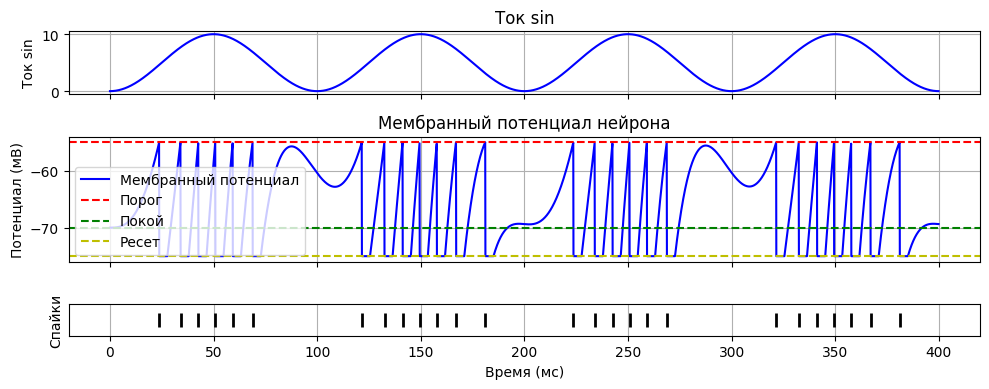

Количество спайков: 26


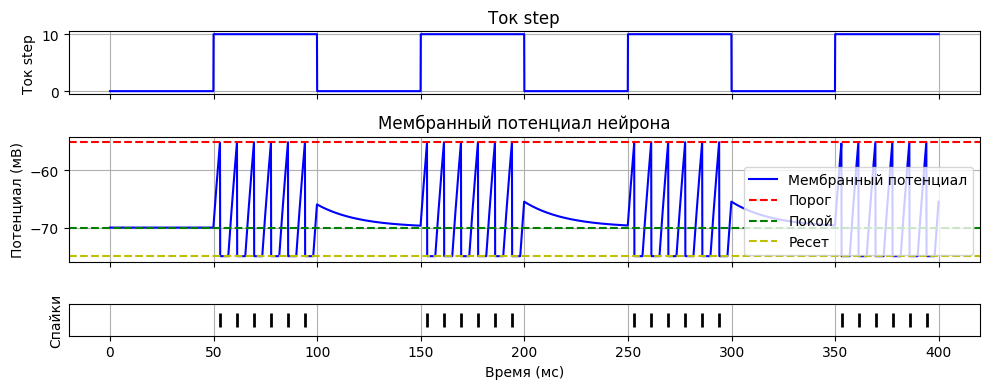

Количество спайков: 24


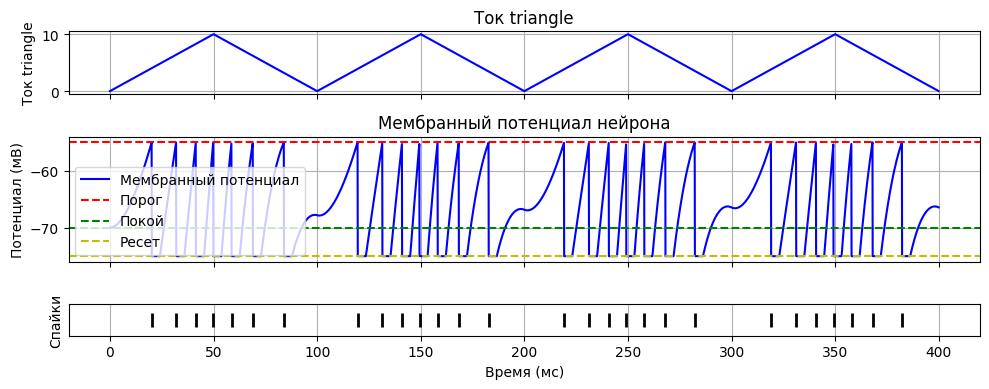

Количество спайков: 28


In [2484]:
dt = 0.1
T = 400
t_range = np.arange(0, T, dt)

for cur in ['sin', 'step', 'triangle']:
    I = get_I_from_type(t_range, cur, A=10, f=4)

    neu = LIFNeuron()

    for i, t in enumerate(t_range):
        neu.step(I[i], dt, t)

    # Визуализация
    # timeplot(t_range, I, f'Ток {cur}', 2)
    plot_neuron_activity(t_range, neu, f'Мембранный потенциал нейрона',
                         top = True, top_label=f'Ток {cur}', top_func=I)
    print(f"Количество спайков: {len(neu.spike_times)}")

In [2485]:
def class_steps(t_range, n_inputs, n_samples, n_sec, pause, A=20):
    I_inj = [np.zeros_like(t_range) for i in range(n_inputs)]
    # mask = np.repeat(np.arange(0, n_inputs), (n_samples // n_inputs))[:len(t_range)]
    mlen = min(len(t_range), n_samples)
    mask = np.repeat(np.arange(0, n_inputs), np.ceil(n_samples / n_inputs))[:mlen]

    np.random.shuffle(mask)
    for i, _ in enumerate(t_range):
        sample = i // (n_sec + pause)
        if i % (n_sec + pause) == 0:
            end = min(i + n_sec, len(t_range))
            I_inj[mask[sample]][i:end] = A
    return I_inj, mask

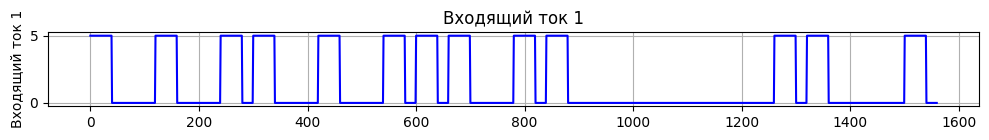

Пиков: 13.0


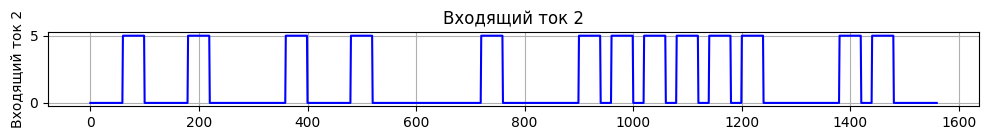

Пиков: 13.0


In [2486]:
n_inputs = 2
n_outputs = 2
A_p = 0.01
A_m = 0.001
tau_p = 20
tau_m = 20

n_sec = 40
pause = 20
n_samples = 26
T = (n_sec + pause) * n_samples
dt = 1
t_range = np.arange(0, T, dt)

I_inj, true_labels = class_steps(t_range, n_inputs, n_samples, n_sec, pause, A=5)

for i in range(n_inputs):
    timeplot(t_range, I_inj[i], f'Входящий ток {i + 1}', height=1.5)
    print(f'Пиков: {len(I_inj[i].nonzero()[0]) / n_sec}')

Сеть из нескольких с STDP

In [2487]:
# np.random.seed(42)
# weights = SNNNetwork.init_weights(n_inputs, n_outputs, set=False, normal=False, A=40)
# weights = SNNNetwork.init_weights(n_inputs, n_outputs, set=False, normal=True, A=5, mu=5)
# weights = SNNNetwork.init_weights(n_inputs, n_outputs, set=True, A=5)

weights = [           # не убирать
    [20.0, 0.0],
    [0.0, 20.0]
]

print(f'Начальные веса:')
display(weights)

model = SNNNetwork(n_inputs, n_outputs, t_range, I_inj, weights, dt, A_p=A_p, A_m=A_m, tau_p=tau_p, tau_m=tau_m)
model.simulate()

Начальные веса:


[[20.0, 0.0], [0.0, 20.0]]

Входы
Вход 1:


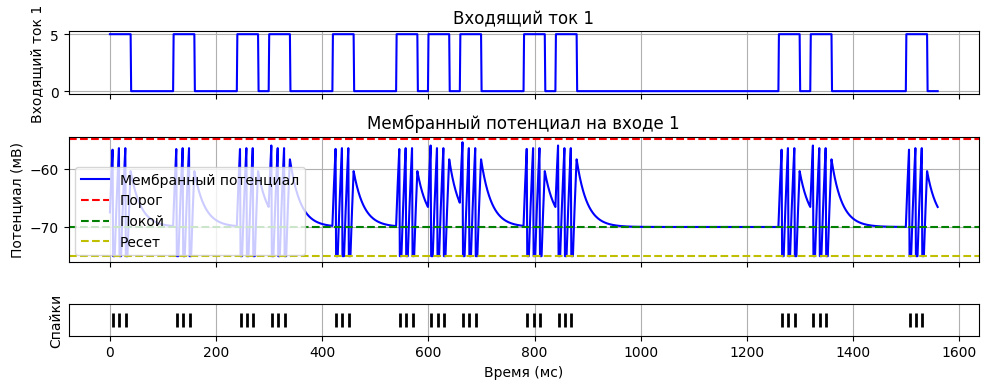

Спайков: 39 (3.0 спайков/образец)
Вход 2:


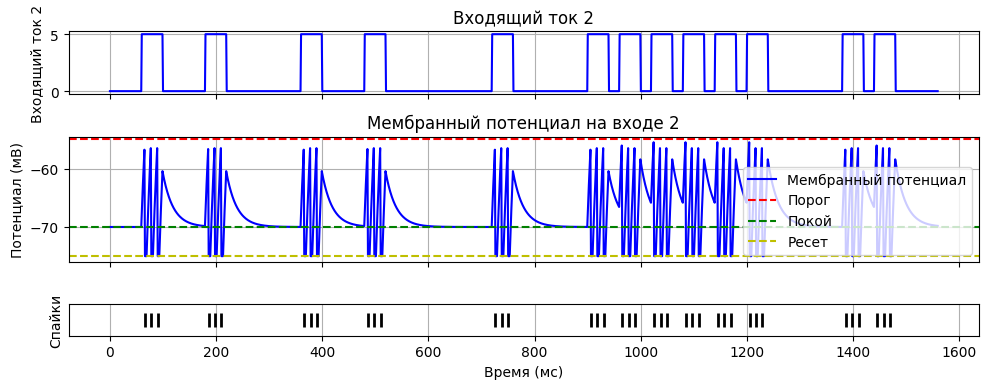

Спайков: 39 (3.0 спайков/образец)
Выходы
Выход 1


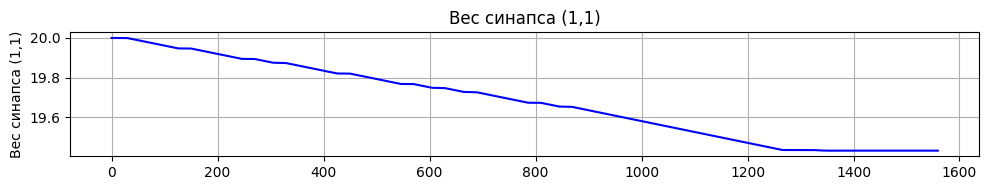

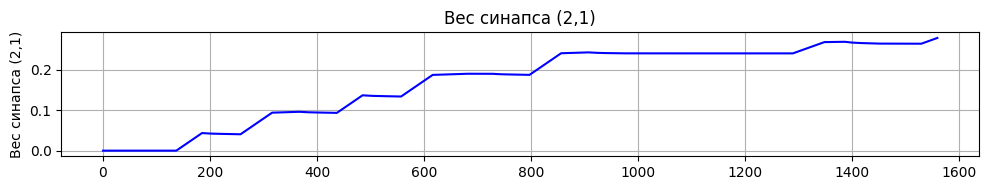

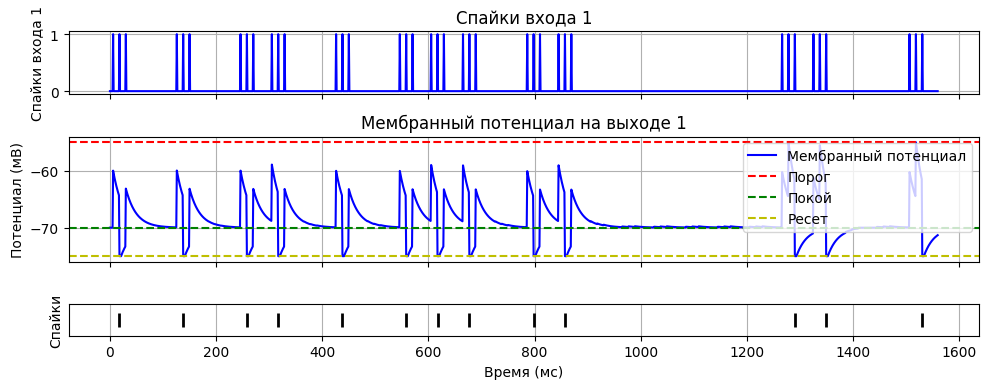

Спайков: 13
Выход 2


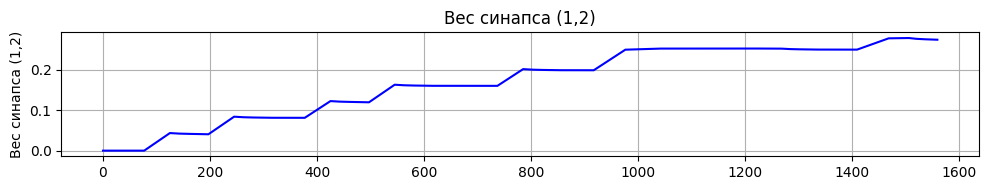

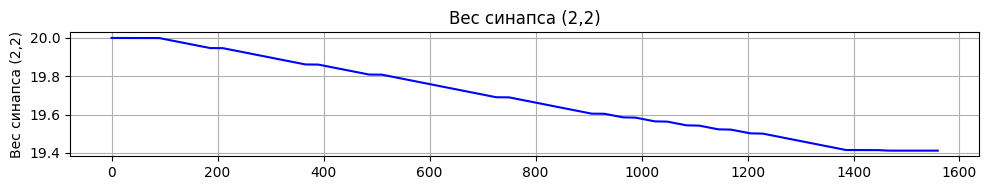

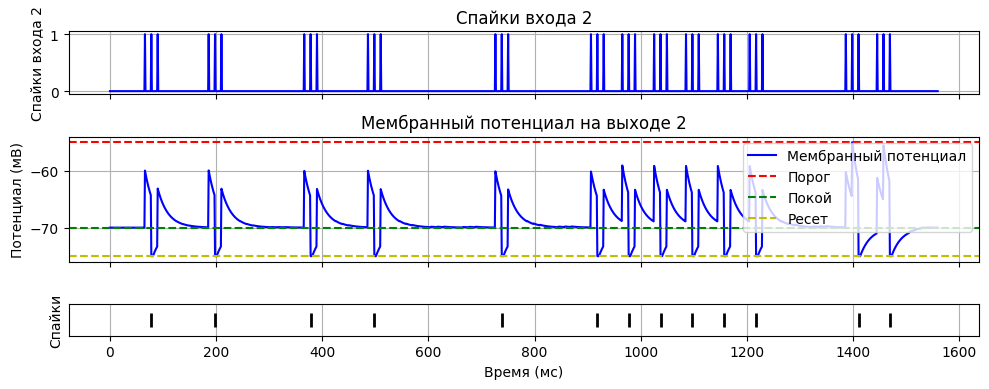

Спайков: 13


In [2488]:
print('Входы')
for i, input in enumerate(model.inputs):
    print(f'Вход {i + 1}:')
    plot_neuron_activity(
        model.t_range, input, f'Мембранный потенциал на входе {i + 1}',
        top=True, top_label=f'Входящий ток {i + 1}', top_func=I_inj[i]
        )
    print(f'Спайков: {len(input.spike_times)} ({len(input.spike_times) / (n_samples // n_inputs)} спайков/образец)')
print('Выходы')
for j, output in enumerate(model.outputs):
    print(f'Выход {j + 1}')
    for i in range(n_inputs):
        timeplot(model.t_range, model.weight_history[i][j], height=2, label=f'Вес синапса ({i + 1},{j + 1})')
    plot_neuron_activity(
        model.t_range, output, f'Мембранный потенциал на выходе {j + 1}',
        top=True, top_label=f'Спайки входа {j + 1}', top_func=[1.0 if t in model.inputs[j].spike_times else 0.0 for i, t in enumerate(t_range)]
        )
    print(f'Спайков: {len(output.spike_times)}')

In [2489]:
def get_pred(model: SNNNetwork, n_samples, n_sec, pause):
    pred_labels = np.zeros(n_samples, dtype=int)

    for sample in range(n_samples):
        t_start = sample * (n_sec + pause)
        t_end = t_start + n_sec

        spike_counts = []
        for j, output in enumerate(model.outputs):
            spike_times = np.array(output.spike_times)
            count = np.sum((spike_times >= t_start) & (spike_times < t_end))
            spike_counts.append(count)
        # print('SP', spike_counts)
        if np.any(spike_counts):
            pred_labels[sample] = np.argmax(spike_counts)
        else:
            pred_labels[sample] = -1
    return pred_labels

In [2490]:
def acc(tp, tn, fp, fn):
    if tp + tn + fp + fn > 0.0:
        return  (tp + tn) / (tp + tn + fp + fn)
    return 0

def prec(tp, fp):
    if tp +  fp > 0.0:
        return (tp) / (tp + fp)
    return 0

def rec(tp, fn):
    if tp + fn > 0.0:
        return (tp) / (tp + fn)
    return 0

def f1(prec, rec):
    if prec + rec > 0.0:
        return  2 * prec * rec / (prec + rec)
    return 0

In [2491]:
def remark_matrix(confusion, model: SNNNetwork):
    mat = np.array(confusion)
    n_classes = model.n_outputs
    submat = mat[1:, 1:]

    row_ind, col_ind = linear_sum_assignment(-submat)

    perm = np.zeros(n_classes, dtype=int)

    for i, j in enumerate(col_ind):
        perm[j] = i

    new_mat = np.zeros_like(mat)
    new_mat[0, :] = mat[0, :]
    new_mat[:, 0] = mat[:, 0]

    for true_idx in range(n_classes):
        new_row = true_idx + 1
        old_row = perm[true_idx] + 1
        for true_col in range(n_classes):
            new_col = true_col + 1
            new_mat[new_row, new_col] = mat[old_row, new_col]

    old_outputs = model.outputs.copy()
    old_weights = [w.copy() for w in model.weights]
    old_weight_history = [wh.copy() for wh in model.weight_history]

    for true_idx in range(n_classes):
        new_row = true_idx + 1
        old_row = perm[true_idx] + 1
        model.outputs[new_row - 1] = old_outputs[old_row - 1]
        for i in range(model.n_inputs):
            model.weights[i][new_row - 1] = old_weights[i][old_row - 1]
            model.weight_history[i][new_row - 1] = old_weight_history[i][old_row - 1]
    return new_mat

In [2492]:
def snn_metrics(y_true, model: SNNNetwork, n_samples, n_sec, pause, verb=False):
    pred_labels = get_pred(model, n_samples, n_sec, pause)

    n_classes = model.n_outputs

    results = {
        'accuracy_micro': 0,
        'accuracy_macro': 0,
        'precision_micro': 0,
        'precision_macro': 0,
        'recall_micro': 0,
        'recall_macro': 0,
        'f1-score_micro': 0,
        'f1-score_macro': 0,
        'misses': 0,
        'confusion': np.zeros((n_classes + 1, n_classes + 1), int)
    }

    # cont_mat = [   
    #     #-1 0  1  y_true
    #     [0, 0, 0],  # -1    y_pred
    #     [0, 0, 0],  # 0
    #     [0, 0, 0]   # 1
    # ]

    for sample in range(n_samples):
        results['confusion'][pred_labels[sample] + 1][y_true[sample] + 1] += 1

    results['confusion'] = remark_matrix(results['confusion'], model)

    tp = np.zeros(n_classes, int)
    tn = np.zeros(n_classes, int)
    fp = np.zeros(n_classes, int)
    fn = np.zeros(n_classes, int)
    
    results['misses'] = sum(results['confusion'][0])

    for i in range(n_classes):
        tp[i] = results['confusion'][i + 1][i + 1]
        fn[i] = np.sum(results['confusion'][:, i + 1]) - tp[i]
        fp[i] = np.sum(results['confusion'][i + 1, :]) - tp[i]
        tn[i] = n_samples - tp[i] - fn[i] - fp[i]

    accuracy = []
    precision = []
    recall = []
    f1_score = []

    # Микро-метрики (усреднение по всем предсказаниям)
    big_tp = np.sum(tp)
    not_missed = n_samples - results['misses']

    results['accuracy_micro'] = big_tp / n_samples if n_samples > 0 else 0.0
    results['precision_micro'] = big_tp / not_missed if not_missed > 0 else 0.0

    for k in range(n_classes):
        accuracy.append(acc(tp[k], tn[k], fp[k], fn[k]))
        precision.append(prec(tp[k], fp[k]))
        recall.append(rec(tp[k], fn[k]))
        f1_score.append(f1(precision[k], recall[k]))

    results['recall_micro'] = big_tp / n_samples  # каждый пример имеет истинный класс
    results['f1-score_micro'] = f1(results['precision_micro'], results['recall_micro'])

    results['accuracy_macro'] = np.mean(accuracy)
    results['precision_macro'] = np.mean(precision)
    results['recall_macro'] = np.mean(recall)
    results['f1-score_macro'] = np.mean(f1_score)
    if verb:
        print(y_true)
        print(pred_labels)
    return results

In [2493]:
# print(f"Точность: {spike_accuracy(true_labels, model, n_samples, n_sec, pause):.4f}")

res = snn_metrics(true_labels, model, n_samples, n_sec, pause)
print(f'Accuracy: {res['accuracy_micro']:.4f}')
print(f'Precision: {res['precision_micro']:.4f}')
print(f'Recall: {res['recall_micro']:.4f}')
print(f'f1-score: {res['f1-score_micro']:.4f}')
print(f'Пропущенных меток: {res['misses']}')
display(res['confusion'])

Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
f1-score: 1.0000
Пропущенных меток: 0


array([[ 0,  0,  0],
       [ 0, 13,  0],
       [ 0,  0, 13]])

In [2494]:
# для нижних (тесты распределений)
n_inputs = 2
n_outputs = 2
# A_p = 0.01
# A_m = 0.012
A_p = 0.2
# A_m = A_p / 1.1
A_m = 0.01
tau_p = 20
tau_m = 20

n_sec = 60
pause = 40
n_samples = 20
T = (n_sec + pause) * n_samples
dt = 1

t_range = np.arange(0, T, dt)

In [2495]:
I_inj, true_labels = class_steps(t_range, n_inputs, n_samples, n_sec, pause, A=10)

weights = SNNNetwork.init_weights(n_inputs, n_outputs, set=False, normal=False, A=20)

print(f'Начальные веса:')
display(np.round(weights, 4))

model = SNNNetwork(n_inputs, n_outputs, t_range, I_inj, weights, dt, A_p=A_p, A_m=A_m, tau_p=tau_p, tau_m=tau_m)

Начальные веса:


array([[18.9777, 19.3126],
       [16.1679,  6.0923]])

In [2496]:
model.simulate()

res = snn_metrics(true_labels, model, n_samples, n_sec, pause)
print(f'Accuracy: {res['accuracy_micro']:.4f}')
print(f'Precision: {res['precision_micro']:.4f}')
print(f'Recall: {res['recall_micro']:.4f}')
print(f'f1-score: {res['f1-score_micro']:.4f}')
print(f'Пропущенных меток: {res['misses']} / {n_samples} ({res['misses'] * 100 / n_samples:.2f} %)')
display(res['confusion'])

Accuracy: 0.5500
Precision: 0.5500
Recall: 0.5500
f1-score: 0.5500
Пропущенных меток: 0 / 20 (0.00 %)


array([[ 0,  0,  0],
       [ 0,  1,  0],
       [ 0,  9, 10]])

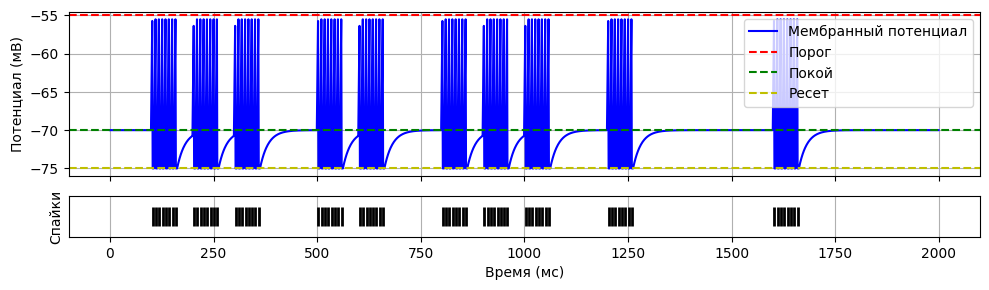

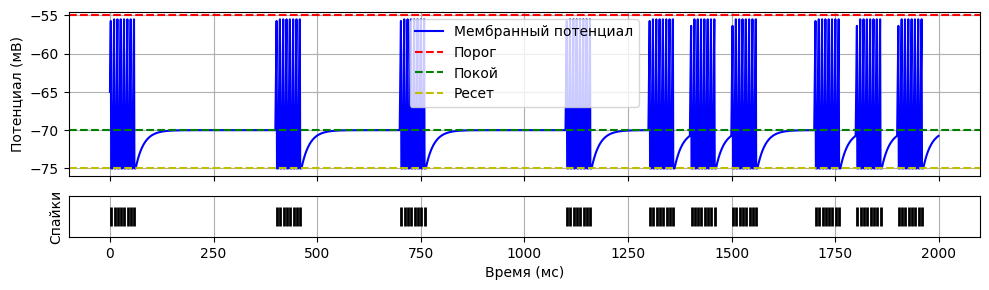

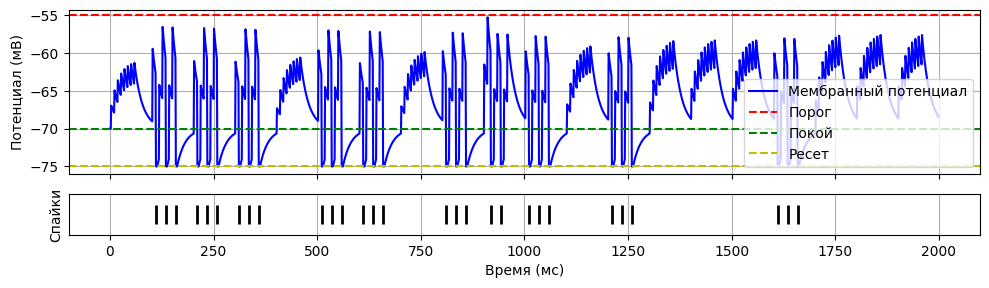

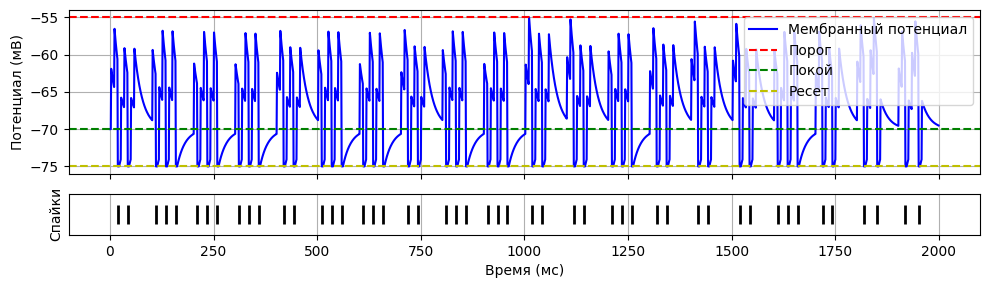

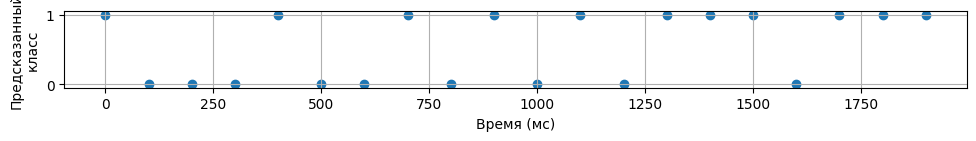

In [2497]:
for j, output in enumerate(model.inputs):
    plot_neuron_activity(t_range, output)
for j, output in enumerate(model.outputs):
    plot_neuron_activity(t_range, output)

pred = get_pred(model, n_samples, n_sec, pause)
xpred = t_range[::n_sec + pause]
fig, ax = plt.subplots(figsize=(10, 1.5))
ax.scatter(xpred, pred)
ax.set_ylabel('Предсказанный\nкласс')
ax.set_xlabel('Время (мс)')
ax.grid(True)
plt.tight_layout()
plt.show()

<Figure size 1000x500 with 0 Axes>

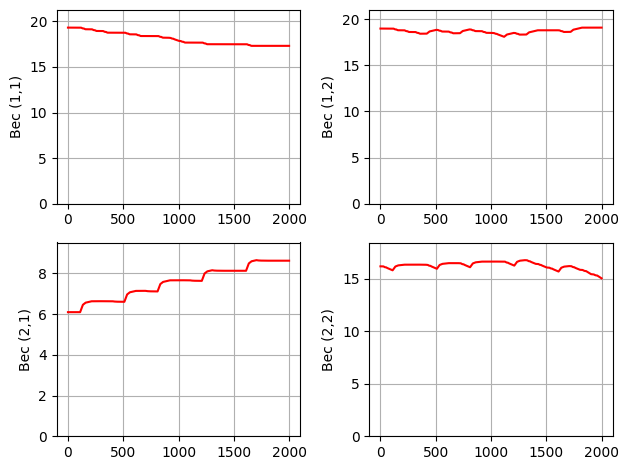

In [2498]:
fig = plt.figure(figsize=(10, 5))

part = len(t_range)
epran_long = np.arange(0, part)
fig, axs = plt.subplots(n_inputs, n_outputs)
for i in range(n_inputs):
    for j in range(n_outputs):
        # whep = [wh[ep][i][j][-1] for ep in epran_long]
        axs[i][j].plot(epran_long, model.weight_history[i][j], 'r', label=f'Вес синапса ({i + 1},{j + 1})')
        axs[i][j].set_ybound(0, np.max(model.weight_history[i][j]) *  1.1)
        axs[i][j].set_ylabel(f'Вес ({i + 1},{j + 1})')
        axs[i][j].grid(True)

plt.tight_layout()
plt.show()

In [2499]:
I_inj, true_labels = class_steps(t_range, n_inputs, n_samples, n_sec, pause, A=10)

weights = SNNNetwork.init_weights(n_inputs, n_outputs, set=False, normal=False, A=20)
# weights = [
#     [40.0, 0.0],
#     [0.0, 40.0]
# ]

print(f'Начальные веса до обучения:')
display(np.round(weights, 4))
# model = SNNNetwork(n_inputs, n_outputs, t_range, I_inj, weights, dt, A_p=A_p, A_m=A_m, tau_p=tau_p, tau_m=tau_m)

epochs = 10

accs = []
wh = []
for ep in range(epochs):

    # I_inj, true_labels = class_steps(t_range, n_inputs, n_samples, n_sec, pause, A=20)

    model = SNNNetwork(n_inputs, n_outputs, t_range, I_inj, weights, dt, A_p=A_p, A_m=A_m, tau_p=tau_p, tau_m=tau_m)

    model.simulate()

    res = snn_metrics(true_labels, model, n_samples, n_sec, pause)
    # display(res['confusion'])
    accuracy = res['accuracy_micro']

    if ep == 0 or (ep + 1) % (epochs // 10) == 0:
        # print(f'Эпоха {ep + 1}/{epochs}, точность (микро): {accuracy:.4f}, веса (средний {np.mean(model.weights):.4f}): {np.round(model.weights, 4)}')
        print(f'Эпоха {ep + 1}/{epochs}, точность (микро): {accuracy:.4f}, веса (средний {np.mean(model.weights):.4f})')
    accs.append(accuracy)
    wh.append(model.weight_history)

Начальные веса до обучения:


array([[19.3917, 15.5027],
       [18.79  , 17.8965]])

Эпоха 1/10, точность (микро): 0.5000, веса (средний 17.4680)
Эпоха 2/10, точность (микро): 0.5000, веса (средний 17.0346)
Эпоха 3/10, точность (микро): 0.5000, веса (средний 17.1298)
Эпоха 4/10, точность (микро): 0.5000, веса (средний 16.9693)
Эпоха 5/10, точность (микро): 0.5000, веса (средний 16.6410)
Эпоха 6/10, точность (микро): 0.5000, веса (средний 16.3947)
Эпоха 7/10, точность (микро): 0.5000, веса (средний 15.9764)
Эпоха 8/10, точность (микро): 0.5000, веса (средний 15.5253)
Эпоха 9/10, точность (микро): 0.5000, веса (средний 15.5146)
Эпоха 10/10, точность (микро): 0.5000, веса (средний 15.7367)


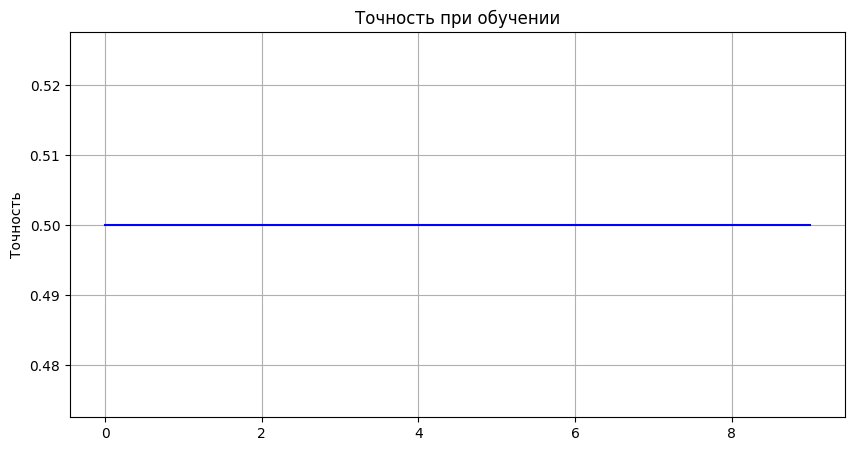

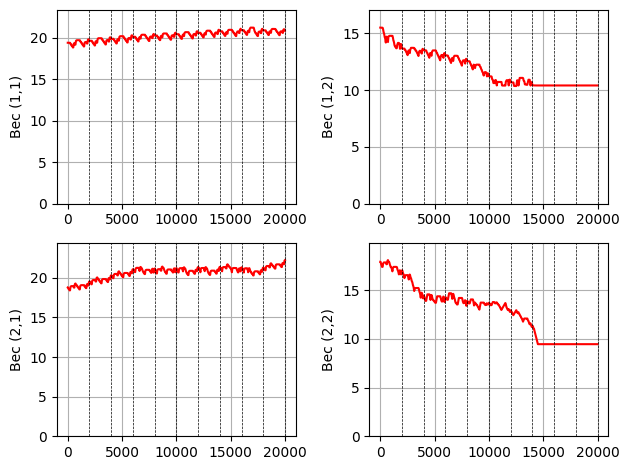

In [2500]:
fig = plt.figure(figsize=(10, 5))

epran = np.arange(0, epochs)
part = len(t_range)
epran_long = np.arange(0, part * epochs)
plt.plot(epran, accs, 'b', label='Тренировочная точность')
plt.title('Точность при обучении')
plt.ylabel('Точность')
plt.grid(True)
whep = np.concat(wh, axis=2)
# print(epran_long.shape, whep.shape)
fig, axs = plt.subplots(n_inputs, n_outputs)
for i in range(n_inputs):
    for j in range(n_outputs):
        # whep = [wh[ep][i][j][-1] for ep in epran_long]
        axs[i][j].plot(epran_long, whep[i][j], 'r', label=f'Вес синапса ({i + 1},{j + 1})')
        for ep in epran:
            axs[i][j].axvline(x=(ep + 1) * part, color='black', linestyle='--', linewidth=0.5)
        axs[i][j].set_ybound(0, np.max(whep[i][j]) * 1.1)
        axs[i][j].set_ylabel(f'Вес ({i + 1},{j + 1})')
        axs[i][j].grid(True)

plt.tight_layout()
plt.show()

In [2501]:
I_inj, true_labels = class_steps(t_range, n_inputs, n_samples, n_sec, pause, A=10)

weights = SNNNetwork.init_weights(n_inputs, n_outputs, set=False, normal=True, mu=20, sigma=4)
# weights = np.clip(weights, 0, 1)

print(f'Начальные веса до обучения:')
display(np.round(weights, 4))

epochs = 10

accs = []
wh = []
for ep in range(epochs):

    # I_inj, true_labels = class_steps(t_range, n_inputs, n_samples, n_sec, pause, A=20)

    model = SNNNetwork(n_inputs, n_outputs, t_range, I_inj, weights, dt, A_p=A_p, A_m=A_m, tau_p=tau_p, tau_m=tau_m)

    model.simulate()

    res = snn_metrics(true_labels, model, n_samples, n_sec, pause)
    # display(res['confusion'])
    accuracy = res['accuracy_micro']

    if ep == 0 or (ep + 1) % (epochs // 10) == 0:
        # print(f'Эпоха {ep + 1}/{epochs}, точность (микро): {accuracy:.4f}, веса (средний {np.mean(model.weights):.4f}): {np.round(model.weights, 4)}')
        print(f'Эпоха {ep + 1}/{epochs}, точность (микро): {accuracy:.4f}, веса (средний {np.mean(model.weights):.4f})')
    accs.append(accuracy)
    wh.append(model.weight_history)

Начальные веса до обучения:


array([[16.6263, 17.9467],
       [19.8259, 18.8988]])

Эпоха 1/10, точность (микро): 0.6500, веса (средний 18.3752)
Эпоха 2/10, точность (микро): 0.6500, веса (средний 18.4686)
Эпоха 3/10, точность (микро): 0.5500, веса (средний 18.6812)
Эпоха 4/10, точность (микро): 0.7000, веса (средний 18.9319)
Эпоха 5/10, точность (микро): 0.5000, веса (средний 19.1130)
Эпоха 6/10, точность (микро): 0.5000, веса (средний 19.2658)
Эпоха 7/10, точность (микро): 0.5000, веса (средний 19.2317)
Эпоха 8/10, точность (микро): 0.5000, веса (средний 19.4868)
Эпоха 9/10, точность (микро): 0.5000, веса (средний 19.8040)
Эпоха 10/10, точность (микро): 0.5000, веса (средний 20.1069)


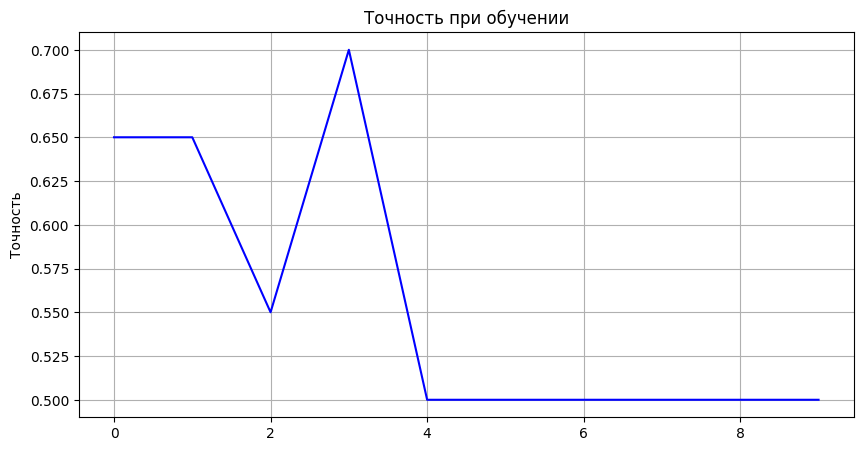

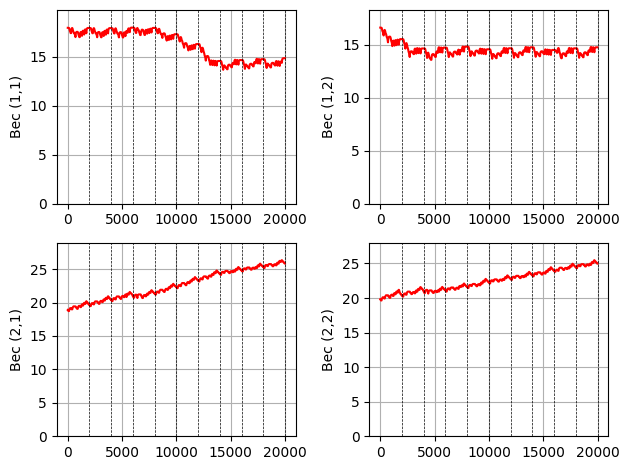

In [2502]:
fig = plt.figure(figsize=(10, 5))

epran = np.arange(0, epochs)
part = len(t_range)
epran_long = np.arange(0, part * epochs)
plt.plot(epran, accs, 'b', label='Тренировочная точность')
plt.title('Точность при обучении')
plt.ylabel('Точность')
plt.grid(True)
whep = np.concat(wh, axis=2)
# print(epran_long.shape, whep.shape)
fig, axs = plt.subplots(n_inputs, n_outputs)
for i in range(n_inputs):
    for j in range(n_outputs):
        # whep = [wh[ep][i][j][-1] for ep in epran_long]
        axs[i][j].plot(epran_long, whep[i][j], 'r', label=f'Вес синапса ({i + 1},{j + 1})')
        for ep in epran:
            axs[i][j].axvline(x=(ep + 1) * part, color='black', linestyle='--', linewidth=0.5)
        axs[i][j].set_ybound(0, np.max(whep[i][j]) * 1.1)
        axs[i][j].set_ylabel(f'Вес ({i + 1},{j + 1})')
        axs[i][j].grid(True)

plt.tight_layout()
plt.show()